In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns

data_dir = Path("data/processed_data")
save_dir = Path("data/final_dataset")
save_dir.mkdir(parents=True, exist_ok=True)

stations = ["BenLuc", "CauNoi", "TanAn"]
feature_cols = ["wind_speed", "temp", "total_precipitation"]


In [4]:
def load_raw(name: str) -> pd.DataFrame:
    path = data_dir / f"{name}_Weather_2020_2025.csv"
    df = pd.read_csv(path)
    df["Time"] = pd.to_datetime(df["Time"])
    n_dup = df.duplicated(subset="Time").sum()
    df = df.drop_duplicates(subset="Time").sort_values("Time").reset_index(drop=True)
    print(f"[{name}] {len(df)} record after {n_dup} being deleted")
    return df
def fix_salinity(series: pd.Series) -> pd.Series:
    s = series.astype(str).str.strip()
    s = s.str.replace(",", ".", regex=False)
    s = s.str.replace(r"^\.+", "", regex=True)
    s = s.str.replace(r"\.{2,}", ".", regex=True)
    return pd.to_numeric(s, errors="coerce")

raw = {}
for s in stations:
    s_loaded = load_raw(s)
    raw[s] = s_loaded

print(raw)

[BenLuc] 8316 record after 0 being deleted
[CauNoi] 8328 record after 0 being deleted
[TanAn] 8328 record after 0 being deleted
{'BenLuc':                     Time Salinity_BenLuc  wind_speed      temp  \
0    2020-01-03 01:00:00             1.6    1.646243  24.85928   
1    2020-01-03 03:00:00             1.2    0.661175  28.42425   
2    2020-01-03 05:00:00             1.1    0.849776  31.32590   
3    2020-01-03 07:00:00             1.4    1.956645  32.16915   
4    2020-01-03 09:00:00             1.7    1.996025  31.83022   
...                  ...             ...         ...       ...   
8311 2025-05-30 15:00:00             0.2    3.097739  27.05114   
8312 2025-05-30 17:00:00             0.3    2.507137  26.88490   
8313 2025-05-30 19:00:00             0.3    2.375268  26.64180   
8314 2025-05-30 21:00:00             0.2    2.061362  26.12540   
8315 2025-05-30 23:00:00             0.2    1.645341  26.23160   

      total_precipitation  
0                0.000000  
1           

In [5]:
for name, df in raw.items():
    sal_col = f"Salinity_{name}"
    bad_mask = pd.to_numeric(df[sal_col].astype(str).str.strip().str.replace(",", ".", regex=False), errors="coerce").isna()
    bad_vals = df.loc[bad_mask, sal_col].value_counts()
    print(f"[{name}] Giá trị lỗi ({bad_mask.sum()} bản ghi):")
    print(bad_vals.to_string() if len(bad_vals) else "  Không có lỗi")
    print()

for name in stations:
    sal_col = f"Salinity_{name}"
    raw[name][sal_col] = fix_salinity(raw[name][sal_col])
    print(f"[{name}] - Remaining: {raw[name][sal_col].isna().sum()}")

[BenLuc] Giá trị lỗi (0 bản ghi):
  Không có lỗi

[CauNoi] Giá trị lỗi (2 bản ghi):
Salinity_CauNoi
.9.5    1
4..2    1

[TanAn] Giá trị lỗi (1 bản ghi):
Salinity_TanAn
.3.3    1

[BenLuc] - Remaining: 0
[CauNoi] - Remaining: 0
[TanAn] - Remaining: 0


In [6]:
for name,df in raw.items():
    gaps = df["Time"].diff()
    big_gaps = gaps[gaps > pd.Timedelta("2h")]
    print(f"[{name}] Khoảng trống > 2h: {len(big_gaps)} lần "
          f"| Max gap: {gaps.max()}")

[BenLuc] Khoảng trống > 2h: 41 lần | Max gap: 580 days 02:00:00
[CauNoi] Khoảng trống > 2h: 41 lần | Max gap: 580 days 02:00:00
[TanAn] Khoảng trống > 2h: 41 lần | Max gap: 580 days 02:00:00


In [7]:
def fill_gaps(df: pd.DataFrame, sal_col: str) -> pd.DataFrame:
    """
    Reindex về lưới 2h đều đặn trong từng năm, sau đó interpolate.
    Không nối xuyên năm để tránh tạo dữ liệu giả giữa các mùa.
    """
    frames = []
    for yr in sorted(df["Time"].dt.year.unique()):
        sub = df[df["Time"].dt.year == yr].copy()
        # tạo lưới 2h từ điểm đầu đến điểm cuối trong năm
        grid = pd.date_range(sub["Time"].min(), sub["Time"].max(), freq="2h")
        sub = sub.set_index("Time").reindex(grid)
        sub.index.name = "Time"
        # interpolate các cột số (giới hạn 5 bước = 10h)
        num_cols = [sal_col] + feature_cols
        sub[num_cols] = sub[num_cols].interpolate(method="linear", limit=5)
        sub = sub.dropna(subset=num_cols)
        sub = sub.reset_index()
        frames.append(sub)
    return pd.concat(frames, ignore_index=True)

cleaned = {}
for name in stations:
    sal_col = f"Salinity_{name}"
    cleaned[name] = fill_gaps(raw[name], sal_col)
    print(f"[{name}] {len(cleaned[name])} bản ghi sau fill_gaps")

cleaned


[BenLuc] 8501 bản ghi sau fill_gaps
[CauNoi] 8513 bản ghi sau fill_gaps
[TanAn] 8513 bản ghi sau fill_gaps


{'BenLuc':                     Time  Salinity_BenLuc  wind_speed      temp  \
 0    2020-01-03 01:00:00              1.6    1.646243  24.85928   
 1    2020-01-03 03:00:00              1.2    0.661175  28.42425   
 2    2020-01-03 05:00:00              1.1    0.849776  31.32590   
 3    2020-01-03 07:00:00              1.4    1.956645  32.16915   
 4    2020-01-03 09:00:00              1.7    1.996025  31.83022   
 ...                  ...              ...         ...       ...   
 8496 2025-05-30 15:00:00              0.2    3.097739  27.05114   
 8497 2025-05-30 17:00:00              0.3    2.507137  26.88490   
 8498 2025-05-30 19:00:00              0.3    2.375268  26.64180   
 8499 2025-05-30 21:00:00              0.2    2.061362  26.12540   
 8500 2025-05-30 23:00:00              0.2    1.645341  26.23160   
 
       total_precipitation  
 0                0.000000  
 1                0.000000  
 2                0.000954  
 3                0.000000  
 4                0.000000 

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from pathlib import Path

STATIONS     = ["BenLuc", "CauNoi", "TanAn"]
COLORS_YEAR  = {2020:"#1E88E5", 2021:"#FB8C00", 2022:"#43A047", 2023:"#E53935", 2025:"#8E24AA"}
COLORS_ST    = {"BenLuc":"#1565C0", "CauNoi":"#2E7D32", "TanAn":"#C62828"}
YEARS        = [2020, 2021, 2022, 2023, 2025]
PLOT_DIR     = Path("outputs/plots")
PLOT_DIR.mkdir(parents=True, exist_ok=True)

cleaned = {s: pd.read_csv(f"data/final_dataset/{s}_clean.csv", parse_dates=["Time"])
           for s in STATIONS}

# Cap outliers tại 99th percentile để tránh spike làm méo trục Y
for name in STATIONS:
    col = f"Salinity_{name}"
    p99 = cleaned[name][col].quantile(0.99)
    cleaned[name][col] = cleaned[name][col].clip(upper=p99)

# Tính trung bình ngày (làm mịn đường)
def daily_mean(df, col):
    df = df.copy()
    df["date"] = df["Time"].dt.normalize()
    return df.groupby("date")[col].mean().reset_index().rename(columns={"date":"Time"})

print("✅ Setup hoàn tất — dữ liệu đã sẵn sàng để vẽ")


✅ Setup hoàn tất — dữ liệu đã sẵn sàng để vẽ


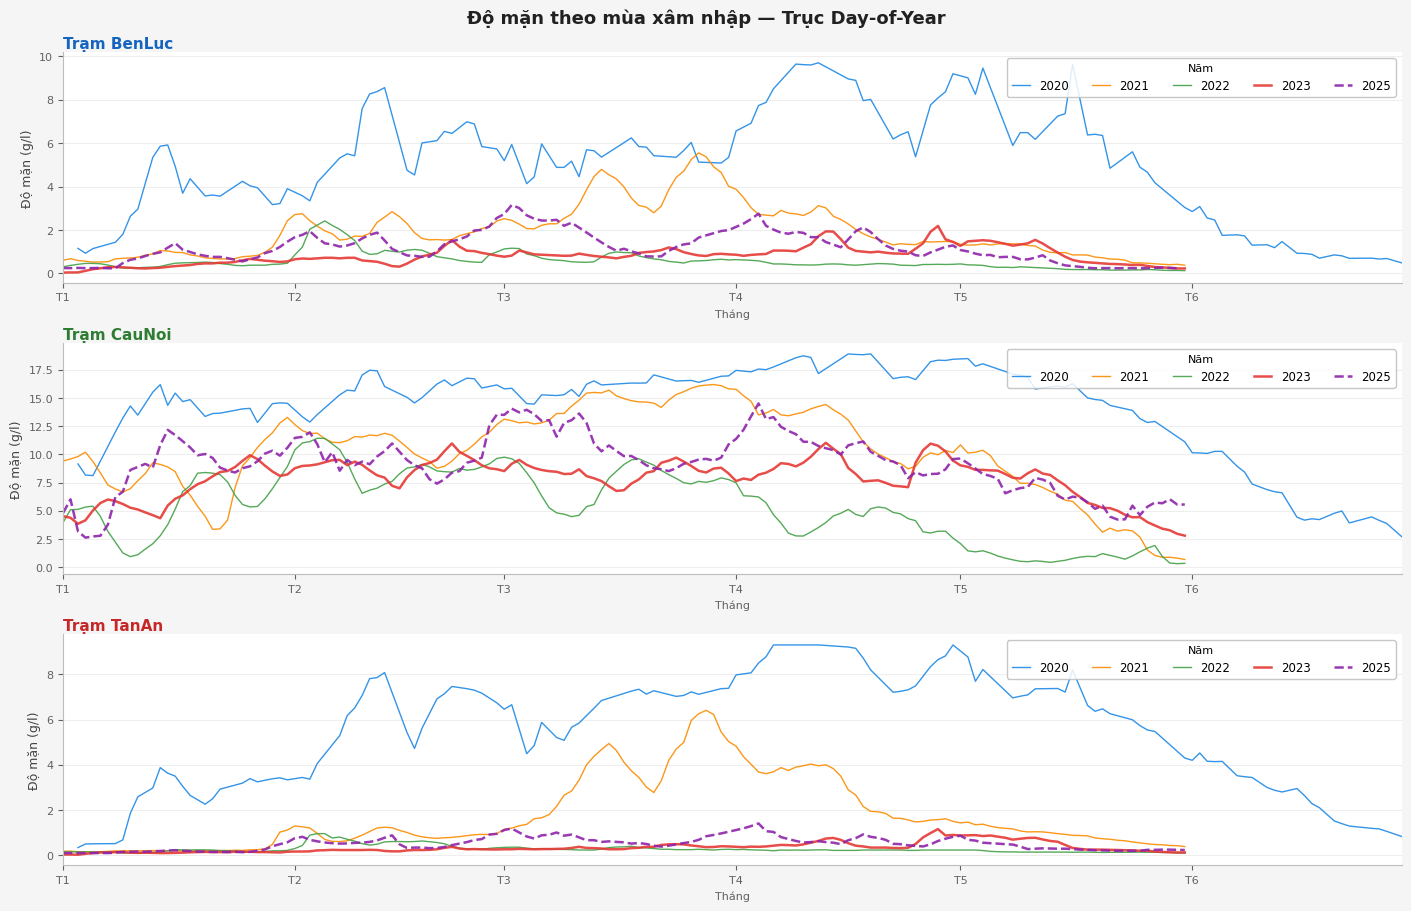

Lưu: viz1_timeseries_doy.png


In [9]:
# ── Biểu đồ 1: Chuỗi thời gian theo Day-of-Year ─────────────────────
fig, axes = plt.subplots(3, 1, figsize=(14, 9), facecolor="#F5F5F5",
                         constrained_layout=True)
fig.suptitle("Độ mặn theo mùa xâm nhập — Trục Day-of-Year",
             fontsize=13, fontweight="bold", color="#212121")

MONTH_DOYS  = [1, 32, 60, 91, 121, 152]
MONTH_NAMES = ["T1","T2","T3","T4","T5","T6"]

for ax, name in zip(axes, STATIONS):
    col = f"Salinity_{name}"
    ax.set_facecolor("white")
    ax.spines[["top","right"]].set_visible(False)
    ax.spines[["left","bottom"]].set_color("#BDBDBD")

    for yr in YEARS:
        sub = cleaned[name][cleaned[name]["Time"].dt.year == yr].copy()
        if sub.empty: continue
        dm = daily_mean(sub, col)
        dm["doy"] = dm["Time"].dt.dayofyear
        lw = 1.8 if yr in [2023, 2025] else 1.0
        ls = "--" if yr == 2025 else "-"
        ax.plot(dm["doy"], dm[col], color=COLORS_YEAR[yr],
                linewidth=lw, linestyle=ls, alpha=0.9, label=str(yr))

    ax.set_ylabel("Độ mặn (g/l)", fontsize=9, color="#424242")
    ax.set_xlabel("Tháng", fontsize=8, color="#616161")
    ax.set_title(f"Trạm {name}", fontsize=11, fontweight="bold",
                 color=COLORS_ST[name], loc="left", pad=3)
    ax.set_xlim(1, 180)
    ax.set_xticks(MONTH_DOYS); ax.set_xticklabels(MONTH_NAMES, fontsize=9)
    ax.tick_params(labelsize=8, colors="#616161")
    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8); ax.set_axisbelow(True)
    lg = ax.legend(title="Năm", fontsize=8.5, title_fontsize=8,
                   framealpha=0.85, loc="upper right", ncol=5, handlelength=1.5)
    lg.get_frame().set_edgecolor("#BDBDBD")

plt.savefig(PLOT_DIR / "viz1_timeseries_doy.png", dpi=140, bbox_inches="tight",
            facecolor="#F5F5F5")
plt.show()
print("Lưu: viz1_timeseries_doy.png")


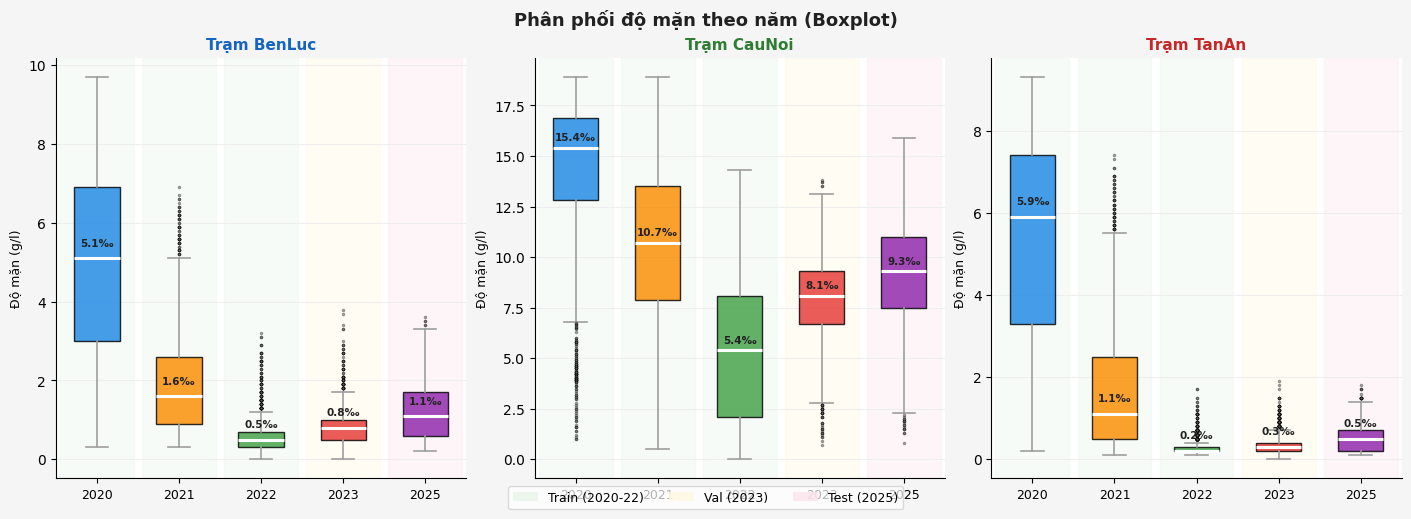

Lưu: viz2_boxplot_yearly.png


In [ ]:
# ── Biểu đồ 2: Boxplot phân phối theo năm ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 5), facecolor="#F5F5F5",
                         constrained_layout=True)
fig.suptitle("Phân phối độ mặn theo năm (Boxplot)", fontsize=13,
             fontweight="bold", color="#212121")

for ax, name in zip(axes, STATIONS):
    col  = f"Salinity_{name}"
    data = [cleaned[name][cleaned[name]["Time"].dt.year == yr][col].dropna().values
            for yr in YEARS]
    bp = ax.boxplot(data, patch_artist=True, notch=False, widths=0.55,
                    medianprops=dict(color="white", linewidth=2.2),
                    whiskerprops=dict(color="#9E9E9E", linewidth=1.2),
                    capprops=dict(color="#9E9E9E", linewidth=1.2),
                    flierprops=dict(marker=".", markersize=3,
                                   markerfacecolor="#BDBDBD", alpha=0.4))
    for patch, yr in zip(bp["boxes"], YEARS):
        patch.set_facecolor(COLORS_YEAR[yr]); patch.set_alpha(0.82)
    for i, med in enumerate(bp["medians"]):
        y_med = med.get_ydata()[0]
        ax.text(i+1, y_med+0.25, f"{y_med:.1f}‰", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold", color="#212121")
    # Tô nền theo split
    for xi, yr in enumerate(YEARS):
        clr = "#E8F5E9" if yr<=2022 else "#FFF8E1" if yr==2023 else "#FCE4EC"
        ax.axvspan(xi+0.55, xi+1.45, color=clr, alpha=0.35, zorder=0)
    ax.set_xticklabels([str(y) for y in YEARS], fontsize=9)
    ax.set_title(f"Trạm {name}", fontsize=11, fontweight="bold", color=COLORS_ST[name])
    ax.set_ylabel("Độ mặn (‰)", fontsize=9)
    ax.set_facecolor("white")
    ax.spines[["top","right"]].set_visible(False)
    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8); ax.set_axisbelow(True)

leg_els = [Patch(facecolor="#E8F5E9",alpha=0.8,label="Train (2020-22)"),
           Patch(facecolor="#FFF8E1",alpha=0.8,label="Val (2023)"),
           Patch(facecolor="#FCE4EC",alpha=0.8,label="Test (2025)")]
fig.legend(handles=leg_els, loc="lower center", ncol=3, fontsize=9,
           framealpha=0.7, bbox_to_anchor=(0.5,-0.02))
plt.savefig(PLOT_DIR / "viz2_boxplot_yearly.png", dpi=140, bbox_inches="tight",
            facecolor="#F5F5F5")
plt.show()
print("Lưu: viz2_boxplot_yearly.png")


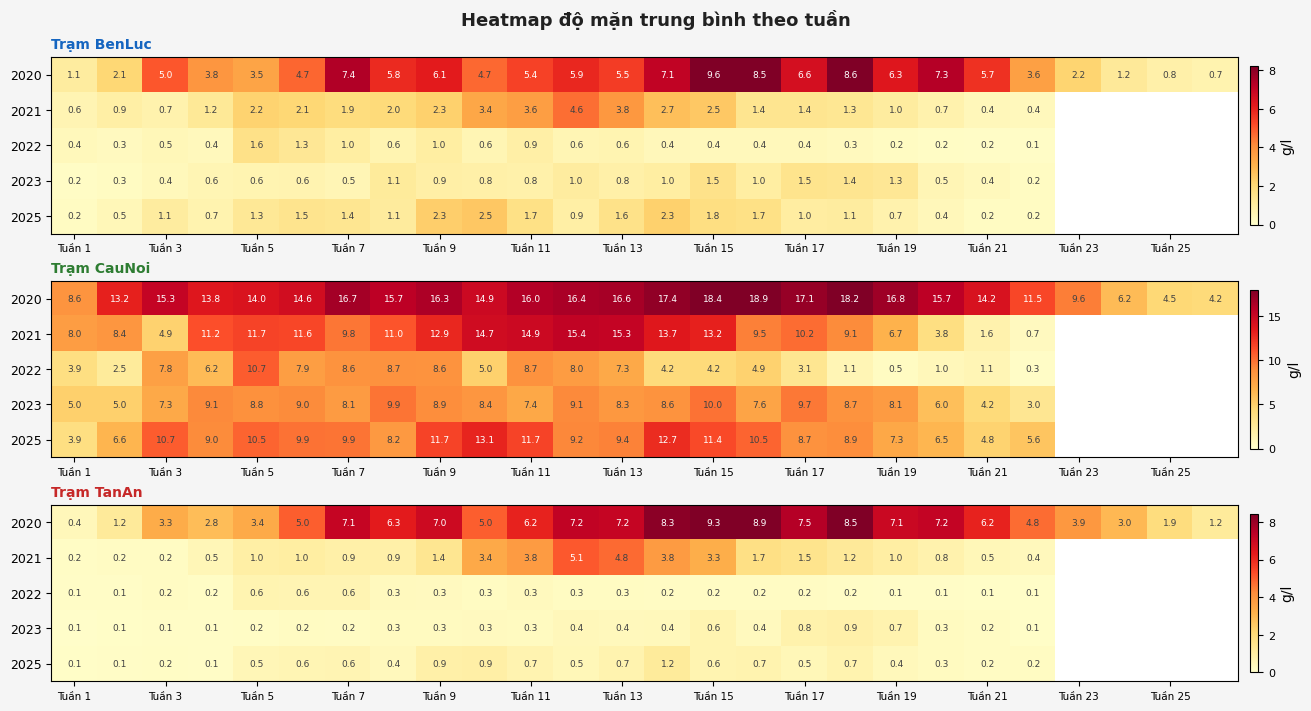

Lưu: viz3_heatmap_weekly.png


In [11]:
# ── Biểu đồ 3: Heatmap độ mặn TB theo tuần ──────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(13, 7), facecolor="#F5F5F5",
                         constrained_layout=True)
fig.suptitle("Heatmap độ mặn trung bình theo tuần",
             fontsize=13, fontweight="bold", color="#212121")

for ax, name in zip(axes, STATIONS):
    col = f"Salinity_{name}"
    df  = cleaned[name].copy()
    df["week"] = df["Time"].dt.isocalendar().week.astype(int)
    df["year"] = df["Time"].dt.year
    pivot = (df.groupby(["year","week"])[col].mean()
               .unstack(level="week")
               .reindex(columns=range(1,27)))
    vals = pivot.values.astype(float)
    vmax = np.nanpercentile(vals, 98)

    im = ax.imshow(vals, aspect="auto", cmap="YlOrRd",
                   vmin=0, vmax=vmax, interpolation="nearest")
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels([str(y) for y in pivot.index], fontsize=9)
    for i in range(vals.shape[0]):
        for j in range(vals.shape[1]):
            if not np.isnan(vals[i,j]):
                txt_clr = "white" if vals[i,j] > vmax*0.6 else "#424242"
                ax.text(j, i, f"{vals[i,j]:.1f}", ha="center", va="center",
                        fontsize=6.5, color=txt_clr)
    ax.set_xticks(range(0,26,2))
    ax.set_xticklabels([f"Tuần {k+1}" for k in range(0,26,2)], fontsize=7.5)
    ax.set_title(f"Trạm {name}", fontsize=10, fontweight="bold",
                 color=COLORS_ST[name], loc="left")
    plt.colorbar(im, ax=ax, shrink=0.9, pad=0.01, label="g/l").ax.tick_params(labelsize=8)

plt.savefig(PLOT_DIR / "viz3_heatmap_weekly.png", dpi=140, bbox_inches="tight",
            facecolor="#F5F5F5")
plt.show()
print("Lưu: viz3_heatmap_weekly.png")


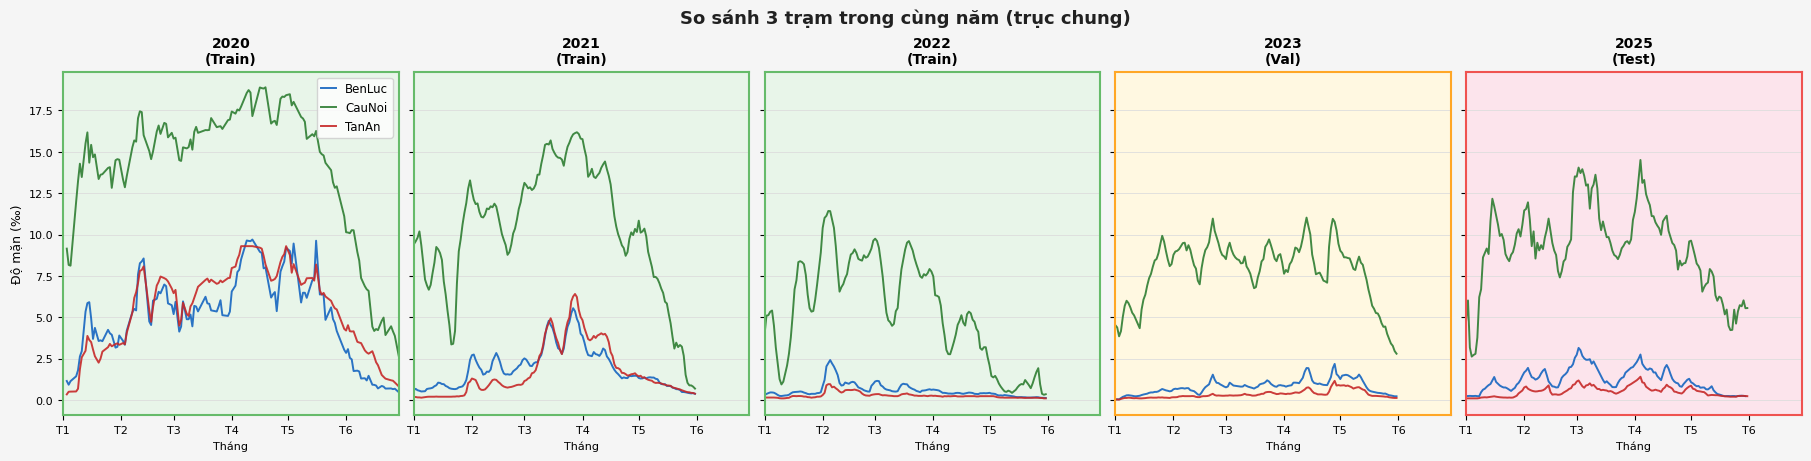

Lưu: viz4_compare_by_year.png

✅ Tất cả biểu đồ đã được lưu vào outputs/plots/


In [13]:
# ── Biểu đồ 4: So sánh 3 trạm theo từng năm ─────────────────────────
split_label  = {2020:"Train",2021:"Train",2022:"Train",2023:"Val",2025:"Test"}
split_bg     = {2020:"#E8F5E9",2021:"#E8F5E9",2022:"#E8F5E9",2023:"#FFF8E1",2025:"#FCE4EC"}
split_border = {2020:"#66BB6A",2021:"#66BB6A",2022:"#66BB6A",2023:"#FFA726",2025:"#EF5350"}

fig, axes = plt.subplots(1, 5, figsize=(18, 4.5), facecolor="#F5F5F5",
                         sharey=True, constrained_layout=True)
fig.suptitle("So sánh 3 trạm trong cùng năm (trục chung)",
             fontsize=13, fontweight="bold", color="#212121")

MONTH_DOYS  = [1, 32, 60, 91, 121, 152]
MONTH_NAMES = ["T1","T2","T3","T4","T5","T6"]

for ax, yr in zip(axes, YEARS):
    ax.set_facecolor(split_bg[yr])
    for spine in ax.spines.values():
        spine.set_edgecolor(split_border[yr]); spine.set_linewidth(1.5)
    for name in STATIONS:
        col = f"Salinity_{name}"
        sub = cleaned[name][cleaned[name]["Time"].dt.year == yr].copy()
        if sub.empty: continue
        dm = daily_mean(sub, col); dm["doy"] = dm["Time"].dt.dayofyear
        ax.plot(dm["doy"], dm[col], color=COLORS_ST[name],
                linewidth=1.4, label=name, alpha=0.9)
    ax.set_title(f"{yr}\n({split_label[yr]})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Tháng", fontsize=8)
    ax.set_xlim(1,180)
    ax.set_xticks(MONTH_DOYS); ax.set_xticklabels(MONTH_NAMES, fontsize=8)
    ax.tick_params(labelsize=8)
    ax.yaxis.grid(True, color="#DDDDDD", linewidth=0.6); ax.set_axisbelow(True)
    if yr == YEARS[0]:
        ax.set_ylabel("Độ mặn (‰)", fontsize=9)
        ax.legend(fontsize=8.5, framealpha=0.8, loc="upper right", handlelength=1.2)

plt.savefig(PLOT_DIR / "viz4_compare_by_year.png", dpi=140, bbox_inches="tight",
            facecolor="#F5F5F5")
plt.show()
print("Lưu: viz4_compare_by_year.png")
print("\n✅ Tất cả biểu đồ đã được lưu vào outputs/plots/")


Ma trận tương quan độ mặn giữa các trạm:


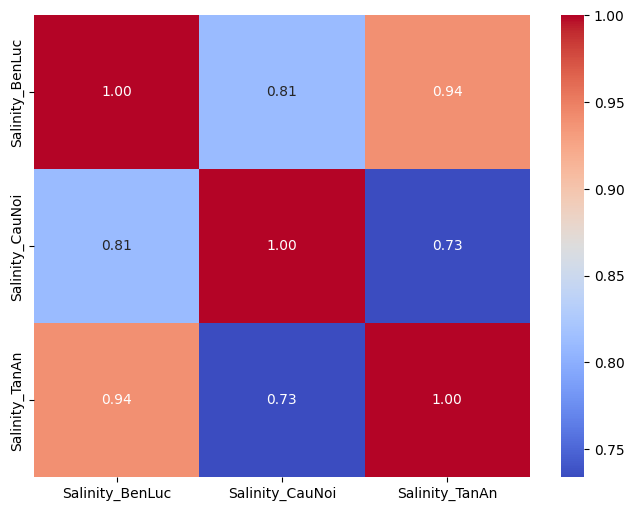

In [12]:
merged_sal = cleaned["BenLuc"][["Time", "Salinity_BenLuc"]].copy()
for name in ["CauNoi", "TanAn"]:
    merged_sal = pd.merge(merged_sal,
                          cleaned[name][["Time", f"Salinity_{name}"]],
                          on="Time", how="inner")

corr = merged_sal[["Salinity_BenLuc","Salinity_CauNoi","Salinity_TanAn"]].corr()
print("Ma trận tương quan độ mặn giữa các trạm:")
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,cmap='coolwarm', fmt='.2f')
plt.show()


In [14]:
for name in stations:
    out_path = save_dir / f"{name}_clean.csv"
    cleaned[name].to_csv(out_path, index=False)
    print(f"Đã lưu: {out_path}  ({len(cleaned[name])} rows)")

print("\n✅ Tiền xử lý hoàn tất! Dữ liệu sẵn sàng cho các kịch bản.")

Đã lưu: data\final_dataset\BenLuc_clean.csv  (8501 rows)
Đã lưu: data\final_dataset\CauNoi_clean.csv  (8513 rows)
Đã lưu: data\final_dataset\TanAn_clean.csv  (8513 rows)

✅ Tiền xử lý hoàn tất! Dữ liệu sẵn sàng cho các kịch bản.


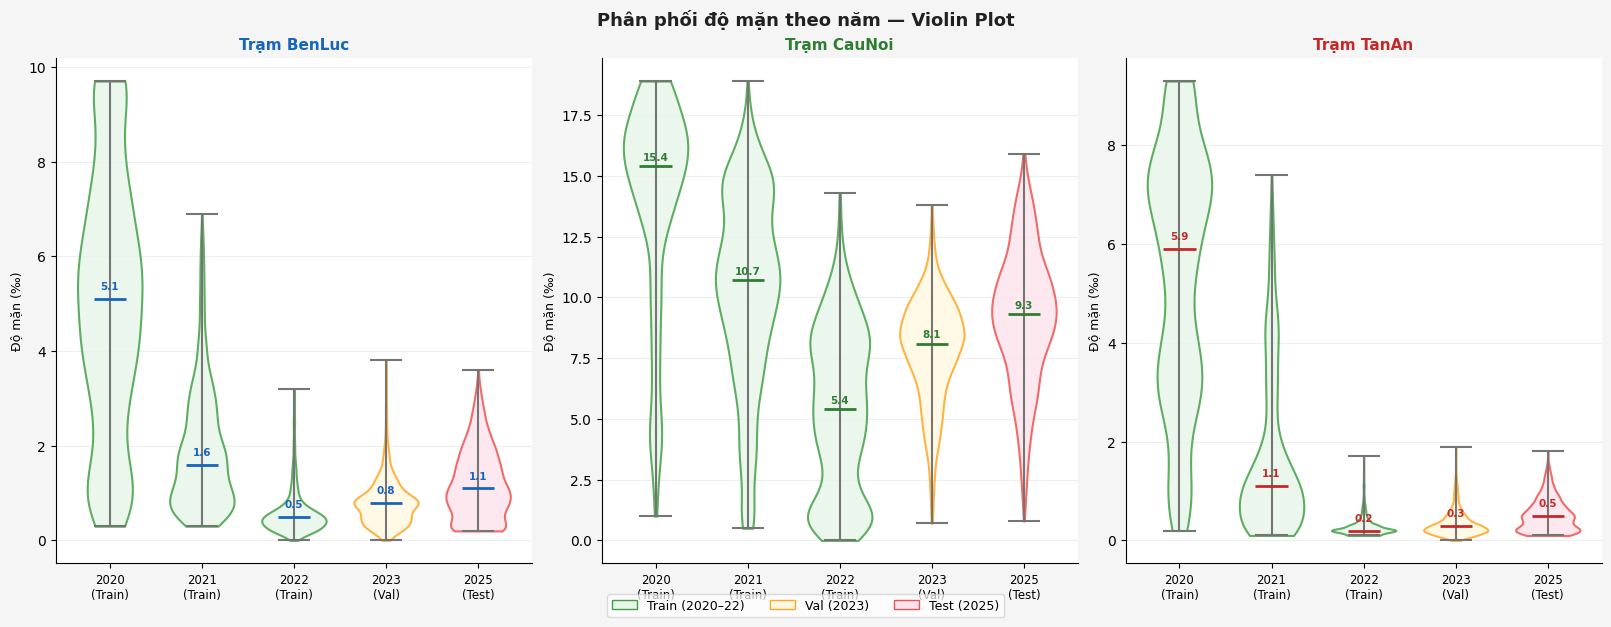

✓ Lưu: outputs/plots/viz_violin.png


In [13]:
# ── Violin Plot: phân phối độ mặn theo trạm × năm ───────────────────
import matplotlib.patches as mpatches

COLORS_ST = {"BenLuc": "#1565C0", "CauNoi": "#2E7D32", "TanAn": "#C62828"}
YEARS     = [2020, 2021, 2022, 2023, 2025]
split_bg  = {2020:"#E8F5E9", 2021:"#E8F5E9", 2022:"#E8F5E9",
             2023:"#FFF8E1", 2025:"#FCE4EC"}
split_lbl = {2020:"Train", 2021:"Train", 2022:"Train",
             2023:"Val",   2025:"Test"}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), facecolor="#F5F5F5",
                         constrained_layout=True)
fig.suptitle("Phân phối độ mặn theo năm — Violin Plot",
             fontsize=13, fontweight="bold", color="#212121")

for ax, name in zip(axes, STATIONS):
    col = f"Salinity_{name}"
    clr = COLORS_ST[name]

    data_by_year = [
        cleaned[name][cleaned[name]["Time"].dt.year == yr][col].dropna().values
        for yr in YEARS
    ]

    parts = ax.violinplot(data_by_year, positions=range(len(YEARS)),
                          showmedians=True, showextrema=True, widths=0.7)

    # Tô màu từng violin theo split
    split_colors = {"Train":"#E8F5E9", "Val":"#FFF8E1", "Test":"#FCE4EC"}
    edge_colors  = {"Train":"#43A047", "Val":"#FFA726", "Test":"#EF5350"}
    for body, yr in zip(parts["bodies"], YEARS):
        lbl = split_lbl[yr]
        body.set_facecolor(split_colors[lbl])
        body.set_edgecolor(edge_colors[lbl])
        body.set_alpha(0.85)
        body.set_linewidth(1.5)

    parts["cmedians"].set_color(clr)
    parts["cmedians"].set_linewidth(2)
    parts["cmaxes"].set_color("#757575")
    parts["cmins"].set_color("#757575")
    parts["cbars"].set_color("#757575")

    # Thêm scatter điểm median annotate
    for xi, yr in enumerate(YEARS):
        med = cleaned[name][cleaned[name]["Time"].dt.year == yr][col].median()
        ax.text(xi, med + 0.15, f"{med:.1f}", ha="center", va="bottom",
                fontsize=7.5, color=clr, fontweight="bold")

    ax.set_title(f"Trạm {name}", fontsize=11, fontweight="bold", color=clr)
    ax.set_xticks(range(len(YEARS)))
    ax.set_xticklabels([f"{yr}\n({split_lbl[yr]})" for yr in YEARS], fontsize=8.5)
    ax.set_ylabel("Độ mặn (‰)", fontsize=9)
    ax.set_facecolor("white")
    ax.spines[["top", "right"]].set_visible(False)
    ax.yaxis.grid(True, color="#EEEEEE", linewidth=0.8)
    ax.set_axisbelow(True)

# Legend phân biệt split
leg_els = [
    mpatches.Patch(facecolor="#E8F5E9", edgecolor="#43A047", label="Train (2020–22)"),
    mpatches.Patch(facecolor="#FFF8E1", edgecolor="#FFA726", label="Val (2023)"),
    mpatches.Patch(facecolor="#FCE4EC", edgecolor="#EF5350", label="Test (2025)"),
]
fig.legend(handles=leg_els, loc="lower center", ncol=3,
           fontsize=9, framealpha=0.7, bbox_to_anchor=(0.5, -0.03))

plt.savefig(PLOT_DIR / "viz_violin.png", dpi=140,
            bbox_inches="tight", facecolor="#F5F5F5")
plt.show()
print("✓ Lưu: outputs/plots/viz_violin.png")

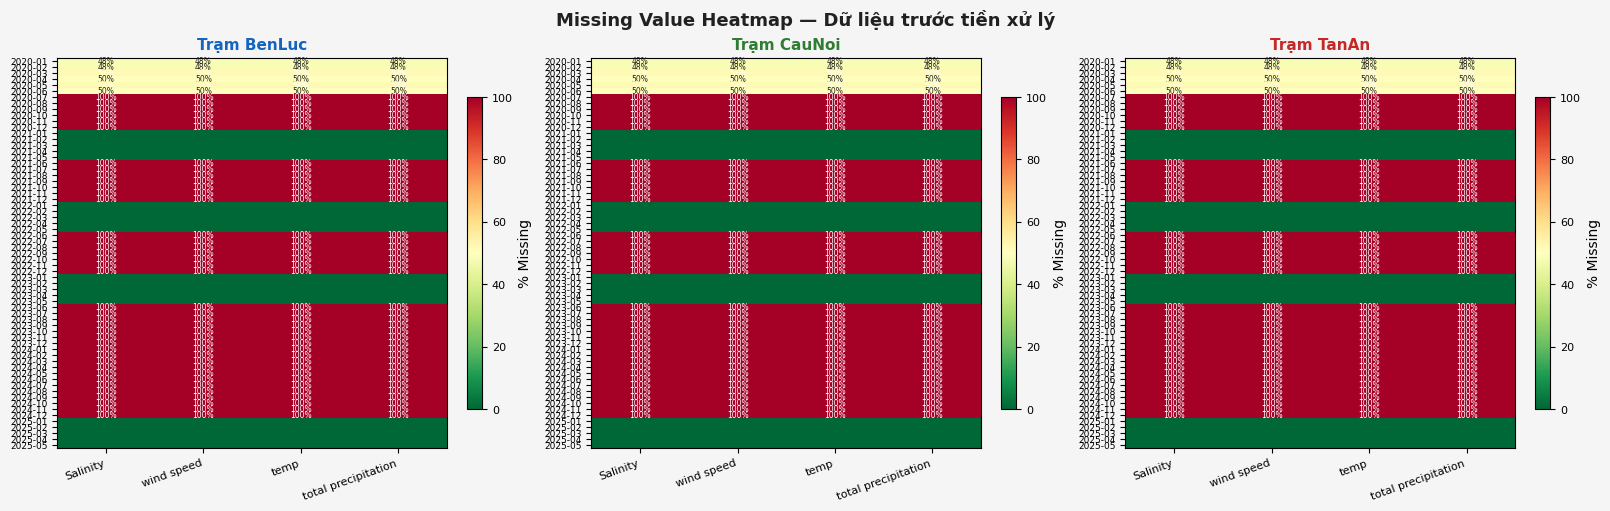

✓ Lưu: outputs/plots/viz_missing_heatmap.png


In [14]:
# ── Missing Value Heatmap ─────────────────────────────────────────────
# Dùng dữ liệu RAW (trước fill_gaps) để thấy khoảng trống thực sự
raw_data = {}
for name in STATIONS:
    path = Path("data/processed_data") / f"{name}_Weather_2020_2025.csv"
    df   = pd.read_csv(path)
    df["Time"] = pd.to_datetime(df["Time"])
    df   = df.drop_duplicates(subset="Time").sort_values("Time").reset_index(drop=True)
    raw_data[name] = df

ALL_COLS = {
    "BenLuc" : ["Salinity_BenLuc",  "wind_speed", "temp", "total_precipitation"],
    "CauNoi" : ["Salinity_CauNoi",  "wind_speed", "temp", "total_precipitation"],
    "TanAn"  : ["Salinity_TanAn",   "wind_speed", "temp", "total_precipitation"],
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor="#F5F5F5",
                         constrained_layout=True)
fig.suptitle("Missing Value Heatmap — Dữ liệu trước tiền xử lý",
             fontsize=13, fontweight="bold", color="#212121")

for ax, name in zip(axes, STATIONS):
    df   = raw_data[name].copy()
    cols = ALL_COLS[name]

    # Reindex về lưới 2h đầy đủ để thấy gap rõ hơn
    full_range = pd.date_range(df["Time"].min(), df["Time"].max(), freq="2h")
    df = df.set_index("Time").reindex(full_range)

    # Matrix: hàng = tháng-năm, cột = biến
    df["ym"] = df.index.to_period("M").astype(str)
    miss_pct = df.groupby("ym")[cols].apply(
        lambda g: g.isna().mean() * 100
    ).reset_index()
    miss_pct = miss_pct.set_index("ym")

    # Vẽ heatmap
    im = ax.imshow(miss_pct.values, aspect="auto",
                   cmap="RdYlGn_r", vmin=0, vmax=100,
                   interpolation="nearest")

    ax.set_yticks(range(len(miss_pct.index)))
    ax.set_yticklabels(miss_pct.index, fontsize=6.5)
    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels([c.replace(f"_{name}", "").replace("_", " ")
                        for c in cols], fontsize=8, rotation=20, ha="right")
    ax.set_title(f"Trạm {name}", fontsize=11, fontweight="bold",
                 color=COLORS_ST[name])

    # Annotate % missing nếu > 0
    for i in range(miss_pct.shape[0]):
        for j in range(miss_pct.shape[1]):
            v = miss_pct.values[i, j]
            if v > 0:
                ax.text(j, i, f"{v:.0f}%", ha="center", va="center",
                        fontsize=5.5,
                        color="white" if v > 50 else "#212121")

    plt.colorbar(im, ax=ax, shrink=0.8,
                 label="% Missing").ax.tick_params(labelsize=8)

plt.savefig(PLOT_DIR / "viz_missing_heatmap.png", dpi=140,
            bbox_inches="tight", facecolor="#F5F5F5")
plt.show()
print("✓ Lưu: outputs/plots/viz_missing_heatmap.png")

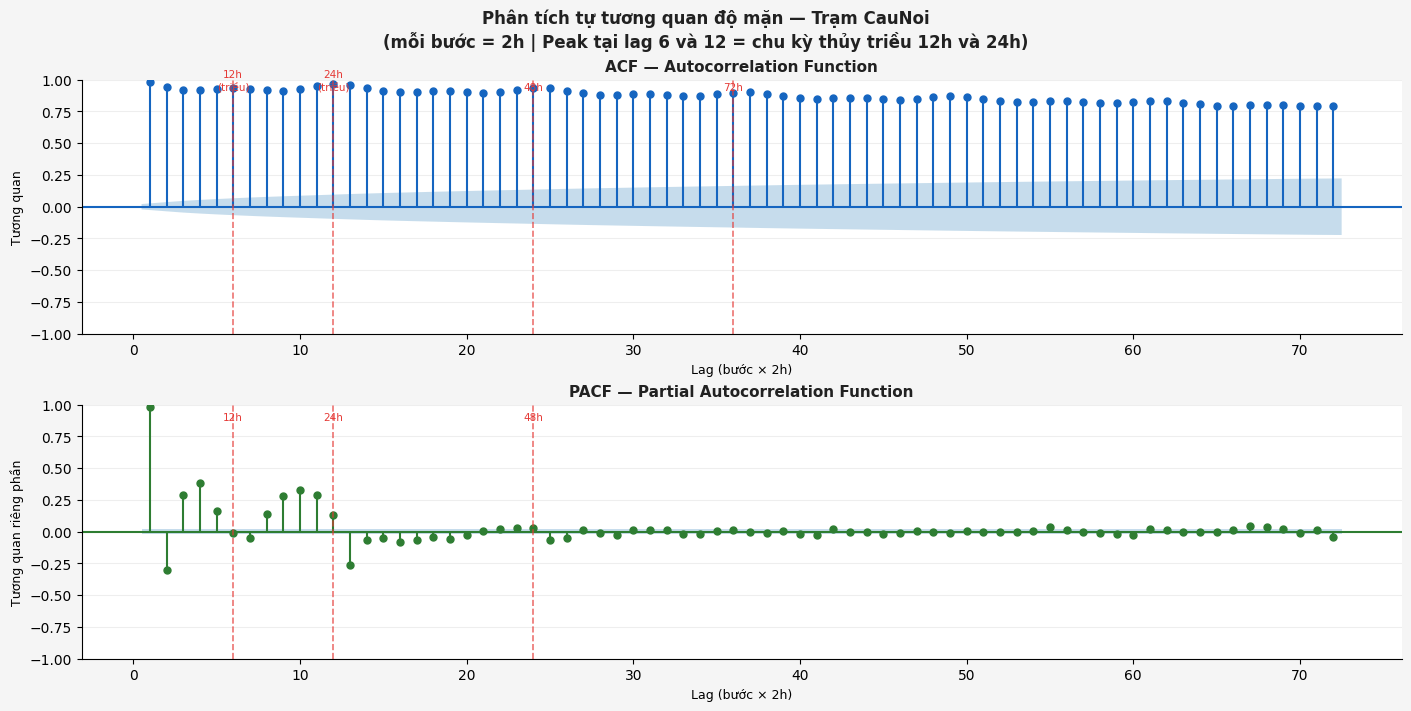

✓ Lưu: outputs/plots/viz_acf_pacf.png

Giải thích:
  ACF  — peak tại lag 6 (12h) và 12 (24h) → chu kỳ thủy triều bán nhật triều
  PACF — drop mạnh sau lag 1-2 → AR order thấp, LSTM đủ với lookback ngắn


In [15]:
# ── ACF và PACF — phân tích cấu trúc tự tương quan ──────────────────
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Dùng CauNoi làm đại diện (dữ liệu sạch nhất, ít zero-diff nhất)
# Lấy toàn bộ chuỗi, chỉ drop NaN
sal_series = cleaned["CauNoi"]["Salinity_CauNoi"].dropna().reset_index(drop=True)
N_LAGS     = 72   # 72 bước × 2h = 144h = 6 ngày — đủ thấy 3 chu kỳ triều

fig, axes = plt.subplots(2, 1, figsize=(14, 7), facecolor="#F5F5F5",
                         constrained_layout=True)
fig.suptitle(
    "Phân tích tự tương quan độ mặn — Trạm CauNoi\n"
    "(mỗi bước = 2h | Peak tại lag 6 và 12 = chu kỳ thủy triều 12h và 24h)",
    fontsize=12, fontweight="bold", color="#212121"
)

# ── ACF ─────────────────────────────────────────────────────────────
plot_acf(sal_series, lags=N_LAGS, ax=axes[0],
         color="#1565C0", vlines_kwargs={"colors": "#1565C0"},
         alpha=0.05, zero=False)
axes[0].set_title("ACF — Autocorrelation Function", fontsize=11,
                  fontweight="bold", color="#212121")
axes[0].set_xlabel("Lag (bước × 2h)", fontsize=9)
axes[0].set_ylabel("Tương quan", fontsize=9)
axes[0].set_facecolor("white")
axes[0].spines[["top", "right"]].set_visible(False)
axes[0].yaxis.grid(True, color="#EEEEEE", linewidth=0.8)
axes[0].set_axisbelow(True)

# Đánh dấu các lag quan trọng
for lag, lbl in [(6,"12h\n(triều)"), (12,"24h\n(triều)"),
                 (24,"48h"), (36,"72h")]:
    axes[0].axvline(lag, color="#E53935", linewidth=1.2,
                    linestyle="--", alpha=0.7)
    axes[0].text(lag, axes[0].get_ylim()[1] * 0.92, lbl,
                 ha="center", fontsize=7.5, color="#E53935")

# ── PACF ────────────────────────────────────────────────────────────
plot_pacf(sal_series, lags=N_LAGS, ax=axes[1], method="ywm",
          color="#2E7D32", vlines_kwargs={"colors": "#2E7D32"},
          alpha=0.05, zero=False)
axes[1].set_title("PACF — Partial Autocorrelation Function", fontsize=11,
                  fontweight="bold", color="#212121")
axes[1].set_xlabel("Lag (bước × 2h)", fontsize=9)
axes[1].set_ylabel("Tương quan riêng phần", fontsize=9)
axes[1].set_facecolor("white")
axes[1].spines[["top", "right"]].set_visible(False)
axes[1].yaxis.grid(True, color="#EEEEEE", linewidth=0.8)
axes[1].set_axisbelow(True)

for lag, lbl in [(6,"12h"), (12,"24h"), (24,"48h")]:
    axes[1].axvline(lag, color="#E53935", linewidth=1.2,
                    linestyle="--", alpha=0.7)
    axes[1].text(lag, axes[1].get_ylim()[1] * 0.88, lbl,
                 ha="center", fontsize=7.5, color="#E53935")

plt.savefig(PLOT_DIR / "viz_acf_pacf.png", dpi=140,
            bbox_inches="tight", facecolor="#F5F5F5")
plt.show()
print("✓ Lưu: outputs/plots/viz_acf_pacf.png")
print()
print("Giải thích:")
print("  ACF  — peak tại lag 6 (12h) và 12 (24h) → chu kỳ thủy triều bán nhật triều")
print("  PACF — drop mạnh sau lag 1-2 → AR order thấp, LSTM đủ với lookback ngắn")